In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import pickle
import glob

import numpy as np
import scipy
import pandas as pd
from scipy.stats import pearsonr, zscore
from scipy.ndimage import convolve1d
import statsmodels

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import r2_score

import imageio.v2 as imageio
import torch
import torch.nn.functional as F
from torchvision import transforms

from utils import align_channels_across_runs, compute_ncsnr_all_timepoints, reshape_electrode_data_by_stimuli, ncsnr_figs, do_retrieval, load_images
# from PSN.psn import psn

from mne.stats import permutation_cluster_1samp_test
from concurrent.futures import ThreadPoolExecutor

# from transformers import CLIPVisionModelWithProjection, CLIPImageProcessor
sys.path.insert(0, os.path.abspath("mindeye_offline"))
import generative_models.sgm as sgm
from generative_models.sgm.modules.encoders.modules import FrozenOpenCLIPImageEmbedder

np.random.seed(42)

/gpfs/milgram/pi/turk-browne/projects/NSD_iEEG_share/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

assert device == "cuda"

Using device: cuda


# load data from a subject

In [4]:
base_dir = '/home/ri99/ieeg'
ieeg_dir = f'{base_dir}/data/subjects/111'
csv_dir = f'{base_dir}/data/nsd_PTB'
img_dir = f'{base_dir}/data/nsd_ecog'

data_dir = f'{base_dir}/data/hfb'
output_dir = f'{base_dir}/outputs/hfb'
cache_dir = f'{base_dir}/.cache'

os.makedirs(cache_dir, exist_ok=True)
sub = 11
n_blocks = -1  # -1 = use all blocks
n_runs = 56

sampling_rate = 1024  # Hz
baseline_time = 0.2  # seconds of data per trial before stimulus onset
# subject 111 had 5600 images split into 4 distinct sessions over 2 days (day 1: runs 1-12 and 13-24; day 2: runs 25-36 and 37-56)

load_from_file = True
smoothing = True

if smoothing:
    window_size = 25
    stride = 10
    smooth_suffix = f'_window{window_size}_stride{stride}'
else:
    smooth_suffix = ''

In [5]:
curric = pd.read_csv(f"{csv_dir}/curriculum_patient{sub}.csv")
curric.head()

,Unnamed: 0,filename,inventory,coco_id,is_repeat,repetition_number,block
0,0,special_23715.png,1x-shared1000_A,23715.0,0,1,1
1,1,notspecial_24264.png,1x-shared1000_A,24264.0,0,1,1
2,2,pair_45_w_pagoda1.png,MST,NaN,0,1,1
3,3,pair_33_nsd_777_1_cocoid_68844.png,MST,68844.0,0,1,1
4,4,notspecial_36682.png,3x-shared1000_A,36682.0,0,1,1


In [6]:
if n_blocks == -1:  # use all available blocks
    block_list = curric['block'].unique().astype(str)
else:  # use n_blocks to specify instead
    block_list = [str(x) for x in range(1, n_blocks+1)]

print(block_list)
image_names = list(curric[curric['block'].isin(block_list)]['filename'])
print(len(image_names))

['1' '2' '3' '4' 'filler_block_1' 'filler_block_2']
5600


In [7]:
# load bipolar-referenced voltage trace data (no frequency decomposition) at 1024Hz
run_list = list(range(1, n_runs+1))

all_data = []
all_labels = []
time_ref = None

for run in tqdm(run_list):
    if load_from_file is False:
        data = np.load(f"{ieeg_dir}/bandpower1024/npy/sub1{sub}_NSD_run{run}_bandpower70-170.npy")
    labels = pd.read_csv(f"{ieeg_dir}/bandpower1024/ch_labels/sub1{sub}_NSD_run{run}_bandpower_channels.csv")
    time = np.load(f"{ieeg_dir}/bandpower1024/time/sub1{sub}_NSD_run{run}_bandpower_time.npy")

    if load_from_file is False:
        assert time.shape[0] == data.shape[2], f"time mismatch in run {run}"
        assert labels.shape[0] == data.shape[1], f"label mismatch in run {run}"
    
    if time_ref is None:
        time_ref = time
    else:
        assert np.allclose(time, time_ref), f"time array differs in run {run}"

    if load_from_file is False:
        all_data.append(data)
    all_labels.append(labels)

if load_from_file is False:
    print(len(all_data))
    del data

# delete to prevent using the wrong ones later; we use channel_info to index channel labels from here on
del labels

100%|██████████| 56/56 [00:00<00:00, 72.42it/s]


In [8]:
if load_from_file is False:
    # combine data across runs while dealing with some runs not having data from the same channels
    data, channel_info = align_channels_across_runs(all_data, all_labels)
    data = data.transpose(1,2,0).astype(np.float32)  # convert to channels x time x trials
    print(f"Final shape: {data.shape}")
    print(channel_info.head())
    channel_info.to_csv(f'{data_dir}/channel_info.csv', index=False)
else:
    channel_info = pd.read_csv(f'{data_dir}/channel_info.csv')

del all_labels

# reshape to identify repeated stimuli

In [9]:
if load_from_file is False:
    # # First, reshape your electrode data using the existing function
    # reshaped_electrode_data, stim_info = reshape_electrode_data_by_stimuli(
    #     data,  # Your electrode data (channels, time, trials)
    #     curric,         # Your events dataframe
    #     stim_column='coco_id'
    # )
    # np.save(f'{data_dir}/reshaped_electrode_data', reshaped_electrode_data)
    # with open(f'{data_dir}/stim_info.pkl', 'wb') as f:
    #     pickle.dump(stim_info, f)
    raise ValueError
else:
    print('loading reduced_data, stim_info from file')
    reduced_data = np.load(f'{output_dir}/top_ncsnr_electrodes_timepoints{smooth_suffix}.npy')
    with open(f'{data_dir}/stim_info.pkl', 'rb') as f:
        stim_info = pickle.load(f)
    print(reduced_data.shape)

loading reduced_data, stim_info from file
(5, 2900, 500, 4)


In [10]:
unique_image_indices = [idx[0] for idx in list(stim_info['stimulus_to_trials'].values())]
assert len(unique_image_indices) == stim_info['n_unique_images']
unique_image_names = pd.unique(curric['filename'])

# sanity checks
assert len(unique_image_indices) == stim_info['n_unique_images']
assert np.all(list(curric['filename'][curric['is_repeat']==0]) == unique_image_names)
assert np.all(list(curric['filename'][curric['repetition_number']==1]) == unique_image_names)

In [11]:
for i in range(len(unique_image_names)):
    # assert the number of available (not NaN) repetitions in the data matches the expected number from the stimulus ordering
    assert int(np.sum(~np.isnan(reduced_data[0,i,0]))) == len(list(stim_info['stimulus_to_trials'].values())[i])

In [12]:
cleaned_data = np.nanmean(reduced_data, axis=3)
print('averaged over repeats')
print(cleaned_data.shape)
del reduced_data

averaged over repeats
(5, 2900, 500)


In [13]:
if load_from_file == False:
    images = utils.load_images(unique_image_names, img_dir=img_dir, save_path=f'{output_dir}/images_torch')
else:
    images = torch.load(f'{output_dir}/images_torch', weights_only=True)

print(images.shape, type(images), images.dtype)
print(images.min(), images.max())

torch.Size([2900, 3, 224, 224]) <class 'torch.Tensor'> torch.float32
tensor(0.) tensor(255.0001)


In [14]:
try:
    print(clip_img_embedder)
except:
    clip_img_embedder = FrozenOpenCLIPImageEmbedder(
        arch="ViT-bigG-14",
        version="laion2b_s39b_b160k",
        output_tokens=True,
        only_tokens=True,
    )
    clip_img_embedder.to(device)
clip_seq_dim = 256
clip_emb_dim = 1664

/gpfs/milgram/pi/turk-browne/projects/NSD_iEEG_share/.venv/lib/python3.10/site-packages/open_clip/factory.py:129: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = 

In [15]:
load_from_file=False

In [16]:
if load_from_file is False:
    try:
        print(clip_img_embedder)
    except NameError:
        clip_img_embedder = FrozenOpenCLIPImageEmbedder(
            arch="ViT-bigG-14",
            version="laion2b_s39b_b160k",
            output_tokens=True,
            only_tokens=True,
        )
        clip_img_embedder.to(device)

    images = load_images(unique_image_names, img_dir, imsize=(224, 224))
    
    assert images.max() > 1.0
    images = images / 255.0

    batch_size = 32
    clip_embeds = []
    
    for i in tqdm(range(0, len(images), batch_size), desc="Generating bigG-14 embeddings"):
        # Move batch to GPU
        batch = images[i:i + batch_size].to(device)
        
        with torch.inference_mode():
            # Returns shape: [batch, 256, 1664] due to output_tokens=True
            outputs = clip_img_embedder(batch)
            
            # Offload to CPU
            clip_embeds.append(outputs.cpu())
    
    clip_image = torch.cat(clip_embeds, dim=0)
    torch.save(clip_image, f'{output_dir}/images_clipemb_bigG')

else:
    clip_image = torch.load(f'{output_dir}/images_clipemb_bigG', map_location='cpu', weights_only=True)

# Final output as numpy
clip_image = clip_image.numpy()

FrozenOpenCLIPImageEmbedder(
  (model): CLIP(
    (visual): VisionTransformer(
      (conv1): Conv2d(3, 1664, kernel_size=(14, 14), stride=(14, 14), bias=False)
      (patch_dropout): Identity()
      (ln_pre): LayerNorm((1664,), eps=1e-05, elementwise_affine=True)
      (transformer): Transformer(
        (resblocks): ModuleList(
          (0-47): 48 x ResidualAttentionBlock(
            (ln_1): LayerNorm((1664,), eps=1e-05, elementwise_affine=True)
            (attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=1664, out_features=1664, bias=True)
            )
            (ls_1): Identity()
            (ln_2): LayerNorm((1664,), eps=1e-05, elementwise_affine=True)
            (mlp): Sequential(
              (c_fc): Linear(in_features=1664, out_features=8192, bias=True)
              (gelu): GELU(approximate='none')
              (c_proj): Linear(in_features=8192, out_features=1664, bias=True)
            )
            (ls_2): Identity()


Generating bigG-14 embeddings:   0%|          | 0/91 [00:00<?, ?it/s]/gpfs/milgram/pi/turk-browne/projects/NSD_iEEG_share/scripts/mindeye_offline/generative_models/sgm/util.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(
Generating bigG-14 embeddings: 100%|██████████| 91/91 [01:44<00:00,  1.15s/it]


In [17]:
cleaned_data = cleaned_data.transpose(1,0,2)

print(f"images shape: {list(images.shape)}, {images.dtype}")
print(f"clip emb shape: {list(clip_image.shape)}")
print(f"ieeg data shape: {list(cleaned_data.shape)}")
print(f"ieeg data interpretation: {cleaned_data.shape[0]} conditions, {cleaned_data.shape[1]} channels, {cleaned_data.shape[2]} timepoints")

images shape: [2900, 3, 224, 224], torch.float32
clip emb shape: [2900, 256, 1664]
ieeg data shape: [2900, 5, 500]
ieeg data interpretation: 2900 conditions, 5 channels, 500 timepoints


In [23]:
# train/test split
x_train, x_test, y_train, y_test, train_idx, test_idx = train_test_split(
    cleaned_data, clip_image, np.arange(cleaned_data.shape[0]), test_size=0.20, random_state=42
)

print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(2320, 5, 500) (580, 5, 500) (2320, 256, 1664) (580, 256, 1664)


In [25]:
# reshape to flatten channels and timepoints
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

y_train = y_train.reshape(y_train.shape[0], -1)
y_test = y_test.reshape(y_test.shape[0], -1)

print(x_train_flat.shape, x_test_flat.shape, y_train.shape, y_test.shape)

(2320, 2500) (580, 2500) (2320, 425984) (580, 425984)


In [26]:
do_pca = True

# no z-scoring at all
x_train_scaled = x_train_flat
x_test_scaled = x_test_flat

# baseline mean subtraction per channel
# take each electrode's baseline signal from -200ms to 0ms
# baseline_data = np.nanmean(reshaped_electrode_data[rankings[:n_reliable_channels], :, :int(np.floor(sampling_rate*0.2))], axis=-1)
# baseline_data = np.delete(baseline_data, 2, axis=0)
# baseline_channel_mean = baseline_data[:,train_idx].mean(axis=1).mean(axis=1)  # per-channel baseline mean for train trials

# x_train_scaled = x_train - baseline_channel_mean.reshape(1,-1,1)
# x_test_scaled = x_test - baseline_channel_mean.reshape(1,-1,1)

# x_train_scaled = x_train_scaled.reshape(x_train_scaled.shape[0], -1)
# x_test_scaled = x_test_scaled.reshape(x_test_scaled.shape[0], -1)

# TODO z-score globally per channel
pass

# z-score per channel per trial
# scaler = StandardScaler()
# x_train_scaled = scaler.fit_transform(x_train_flat)
# x_test_scaled = scaler.transform(x_test_flat)

print(x_train_scaled.shape, x_test_scaled.shape, y_train.shape, y_test.shape)

(2320, 2500) (580, 2500) (2320, 425984) (580, 425984)


131 PCs explain 0.98 of the variance


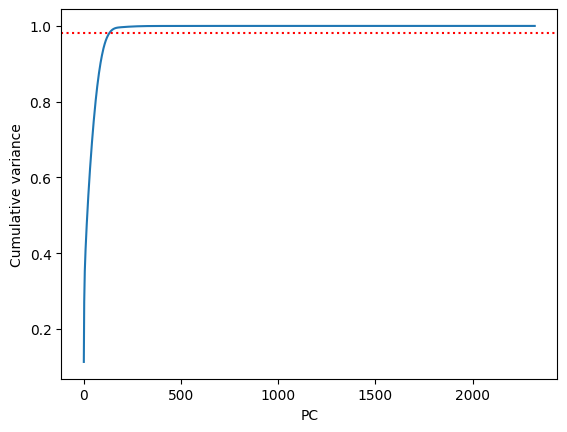

In [27]:
if do_pca == True:
    from sklearn.decomposition import PCA
    
    # Flatten to (conditions, channels*time)
    pca = PCA().fit(x_train_scaled)
    plt.plot(np.cumsum(pca.explained_variance_ratio_))
    plt.xlabel('PC'); plt.ylabel('Cumulative variance')
    
    x = 0.98
    plt.axhline(x, c='r', linestyle=':')
    n_pcs_x = np.searchsorted(np.cumsum(pca.explained_variance_ratio_), x) + 1
    print(f"{n_pcs_x} PCs explain {x} of the variance")
    
    plt.show()

1517 PCs explain 0.8 of the variance


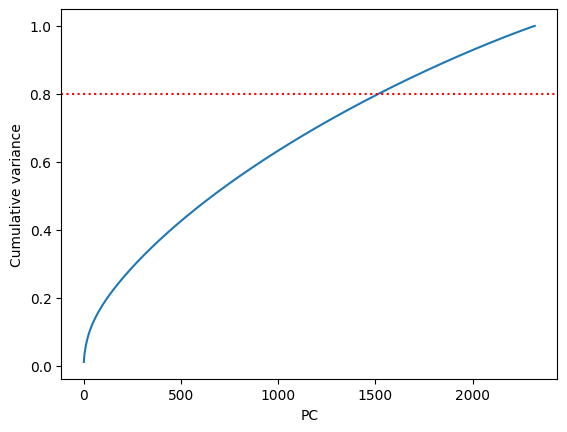

In [28]:
pca = PCA().fit(y_train)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('PC'); plt.ylabel('Cumulative variance')

x = 0.8
plt.axhline(x, c='r', linestyle=':')
n_pcs_y = np.searchsorted(np.cumsum(pca.explained_variance_ratio_), x) + 1
print(f"{n_pcs_y} PCs explain {x} of the variance")

plt.show()

In [29]:
print(x_train_scaled.shape, x_test_scaled.shape, y_train.shape, y_test.shape)

if do_pca == True:
    pca = PCA(n_components=n_pcs_x)
    x_train_scaled = pca.fit_transform(x_train_scaled)
    x_test_scaled = pca.transform(x_test_scaled)

    clip_pca = PCA(n_components=n_pcs_y)
    y_train = clip_pca.fit_transform(y_train)
    y_test = clip_pca.transform(y_test)

print(x_train_scaled.shape, x_test_scaled.shape, y_train.shape, y_test.shape)

(2320, 2500) (580, 2500) (2320, 425984) (580, 425984)
(2320, 131) (580, 131) (2320, 1517) (580, 1517)


In [30]:
# Set up ridge regression
ridge_model = RidgeCV(alphas=np.logspace(-4, 6, 50), alpha_per_target=True)
ridge_model.fit(x_train_scaled, y_train)
y_pred_train = clip_pca.inverse_transform(ridge_model.predict(x_train_scaled))
y_pred_test  = clip_pca.inverse_transform(ridge_model.predict(x_test_scaled))

coef_of_det = ridge_model.score(x_test_scaled, y_test)
print(f'R^2 (coefficient of determination): {coef_of_det:.2f}')

R^2 (coefficient of determination): -0.01


In [31]:
# simple retrieval only works if there's no repeats
assert len(cleaned_data) == len(unique_image_names)

In [32]:
top_k = 5

train_acc, train_sims = do_retrieval(x_train_scaled, clip_pca.inverse_transform(y_train), y_pred_train, top_k=top_k)
test_acc, test_sims = do_retrieval(x_test_scaled, clip_pca.inverse_transform(y_test), y_pred_test, top_k=top_k)
print(f"train fwd acc: {train_acc:.2%}, test fwd acc: {test_acc:.2%}")

train fwd acc: 0.60%, test fwd acc: 1.72%


In [33]:
# permutation test: shuffle predictions and recompute accuracy 1000 times
null_accs = []
for _ in tqdm(range(1000)):
    shuffled = y_pred_test[np.random.permutation(len(y_pred_test))]
    acc, _ = do_retrieval(x_test_scaled, clip_pca.inverse_transform(y_test), shuffled, top_k=top_k)
    null_accs.append(acc)

p_val = np.mean(np.array(null_accs) >= test_acc)
print(f"p-value: {p_val:.4f}, null mean: {np.mean(null_accs):.2%}, null 95th pct: {np.percentile(null_accs, 95):.2%}")

  4%|▎         | 36/1000 [12:10<5:25:55, 20.29s/it]


KeyboardInterrupt: 

NameError: name 'p_val' is not defined

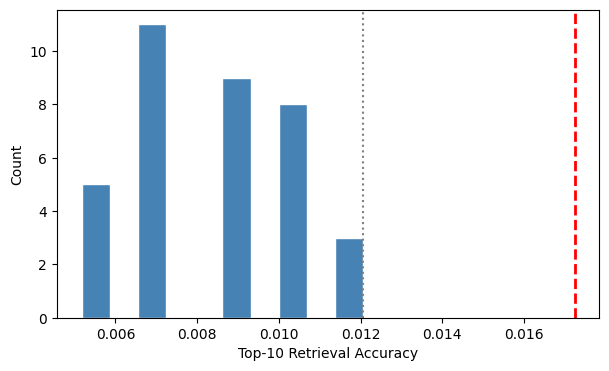

In [34]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(null_accs, bins=10, color='steelblue', edgecolor='white', label='Null distribution')
ax.axvline(test_acc, color='red', linewidth=2, linestyle='--', label=f'True accuracy ({test_acc:.2%})')
ax.axvline(np.percentile(null_accs, 95), color='gray', linewidth=1.5, linestyle=':', label='95th percentile null')

ax.set_xlabel('Top-10 Retrieval Accuracy')
ax.set_ylabel('Count')
ax.set_title(f'Permutation Test (p={p_val:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

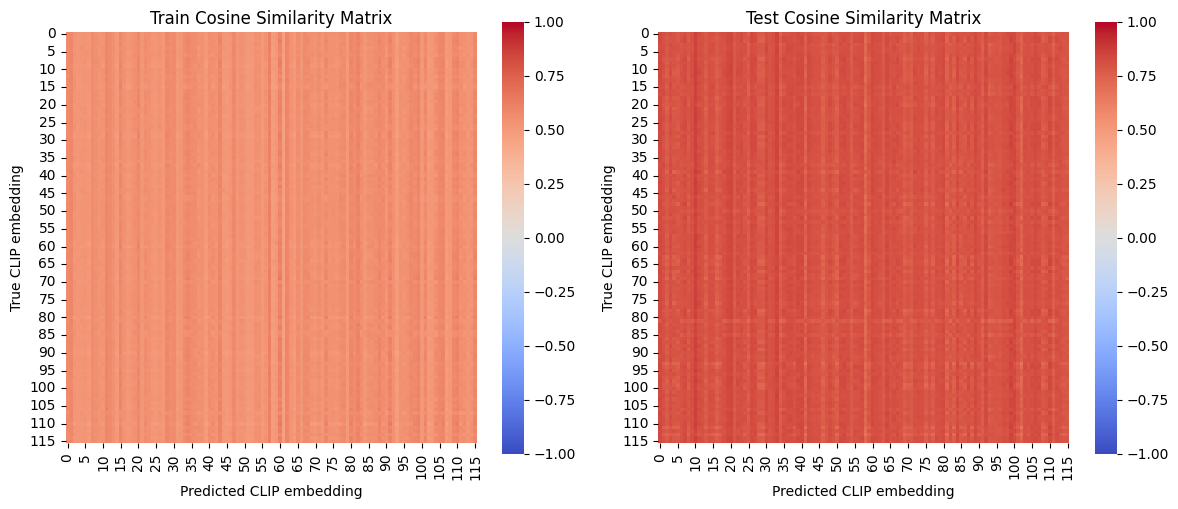

In [35]:
# print('displaying every 20 train images and every 5 test images')

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(train_sims[::20, ::20], vmin=-1, vmax=1, cmap="coolwarm", square=True, ax=axs[0])
axs[0].set_title("Train Cosine Similarity Matrix")
axs[0].set_xlabel("Predicted CLIP embedding")
axs[0].set_ylabel("True CLIP embedding")

sns.heatmap(test_sims[::5, ::5], vmin=-1, vmax=1, cmap="coolwarm", square=True, ax=axs[1])
axs[1].set_title("Test Cosine Similarity Matrix")
axs[1].set_xlabel("Predicted CLIP embedding")
axs[1].set_ylabel("True CLIP embedding")

plt.tight_layout()
plt.show()